# Character Segmentation

Here we use histogram methods to identify border boxes

Limitations (a lot):
- Text needs decently clear background
- Extremely sensitive to Hyperparameters
- Rotated or distorted text doesn't behave well
- Very messy handwritting will missegmentate

Solution? idk, maybe try pre built models or something?

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import tensorflow as tf
from PIL import Image
from pathlib import Path

model = tf.keras.models.load_model("drive/MyDrive/ETL9B/KanjiOCR_3-0.keras")

with open("drive/MyDrive/ETL9B/Class2Number.json", "r", encoding="utf-8") as f:
    Character2Number = json.load(f)
Number2Letter = {int(k): v for k, v in Character2Number.items()}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 2 · Hyper Params

In [3]:
IMAGE_PATH = "drive/MyDrive/ETL9B/ComputerSegmentationTest.png"  
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest.png"   
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest (1).png"
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest3.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/OldSegmentationTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuSegmentationTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/TVSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuruHandwrittenTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/YourNameHandwrittenTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/BookData/Karafuru_1.png"

ORIENTATION = 1 # 0/1 Horizontal/Vertical

BINARISE_THRESHOLD = 127 #Irrelevant now that we use Otsu's

# Thresholds to identify lines and characters based on their perpendicular intensity
# Note: Threshold is relative to the max value of the projection

LINE_INK_THRESHOLD = 0.02
CHAR_INK_THRESHOLD = 0.0

#Lines with gaps smaller than 4 pixels get merged
#Would be nice to change this maybe to a relative method like the one above
LINE_MERGE_GAP = 4

#Lines smaller than 4 pixels get discarded
#Same comment from the previous hyperparam
LINE_MIN_HEIGHT = 4

#Same but for characters
CHAR_MERGE_GAP = 4
CHAR_MIN_WIDTH = 1

#Confidence threshold doesn't really matter for current model bc the guy has always hella confidence
CONFIDENCE_THRESHOLD = 0.05
#How many "guesses" the model gives us
TOP_N = 5

#Max and min aspect ratios for character segmentation alongside their recursive adjustment factors
MAX_FATNESS = 1.2
THRESHOLD_INCREASE_ON_FATTIE = 0.05

MAX_THINNESS = 0.5
SMOOTHING_FACTOR = 0.55

#When orientation is vertical we swap stuff
if ORIENTATION == 1:
    LINE_MERGE_GAP, CHAR_MERGE_GAP = CHAR_MERGE_GAP, LINE_MERGE_GAP
    LINE_MIN_HEIGHT, CHAR_MIN_WIDTH = CHAR_MIN_WIDTH, LINE_MIN_HEIGHT

##### Functions

In [4]:

def ShowProj(img):
    plt.imshow(img[np.newaxis, :], aspect='auto', cmap='viridis')
    plt.show()

def ShowImage(img):
    plt.imshow(img, cmap="binary_r")
    plt.show()

def LoadBinary(path):
    
    greyscale = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    
    _, binary = cv2.threshold(greyscale, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return greyscale, binary


def FindLimits(proj, threshold, gap):
    
    max = np.max(proj)
    relativeThreshold = max*threshold
    
    #print(f"Relative Thres {threshold} of max {max} is {relativeThreshold}")

    limits  = []
    
    in_char = False
    start =  0
    
    for i, val in enumerate(proj):
        if not in_char and val >= relativeThreshold: #Going into a Character
            in_char = True
            start = i
        elif in_char and val < relativeThreshold: #Going out of Character
            in_char = False
            limits.append((start, i - 1))
            
    if in_char:
        limits.append((start, len(proj) - 1)) #In case we end loop in_char
        
    #print(f"Limits before merging: {limits}")

    merged = []
    for limit in limits:
        if merged and limit[0] - merged[-1][1] <= gap:
            merged[-1] = (merged[-1][0], limit[1])
        else:
            merged.append(list(limit))
    return merged


def DetectLines(binary, threshold, gap, orientation):
    projH = binary.sum(axis = 1 if orientation==0 else 0) 
    
    return FindLimits(projH, threshold, gap)


def DetectCharacters(binarySentence, threshold, gap, minW, maxFatness, maxThiness, lineH, orientation):
    projV = binarySentence.sum(axis=orientation)   
    limits = FindLimits(projV, threshold, gap)
    
    #print(binarySentence.shape)
    
    #Big problems to solve here:
    #1 - Tiny irrelevant characters
    #2 - Kanjis with empty space in between, like 能
    #3 - Kanji pairs getting connected toghether
    
    filtered = [(start, end) for start, end in limits if end - start + 1 >= minW]
    
    noFatties = []
    for limit in filtered:
        start, end = limit
        if end - start + 1 > lineH * maxFatness:
            if gap == 0:
                noFatties.append(limit)
            else:
                #print("Fattie detected")
                unfatties = DetectCharacters(binarySentence[start:end, :] if orientation == 1 else binarySentence[:, start:end], threshold + THRESHOLD_INCREASE_ON_FATTIE, gap-1, minW, maxFatness, maxThiness, lineH, orientation)
                
                for u in unfatties:
                    s,e= u
                    noFatties.append((start+s, start+e))
        else:
            noFatties.append(limit)
            
    # print(f"No fatties: {maxFatness}")
    # print(f"No lankys: {maxThiness}")
    noLankys = []
    for i, limit in enumerate(noFatties):
        if i == len(noFatties) - 1:
            noLankys.append(limit)
            continue
        
        start, end = limit
        if end - start + 1 < lineH * maxThiness:
            nextStart, nextEnd = noFatties[i+1]
            if nextEnd - nextStart + 1 < lineH / maxThiness and not(nextEnd - start + 1 > lineH * maxFatness):
                
                #print("Lanky pair detected")
                noFatties.remove(noFatties[i+1])
                noLankys.append((start, nextEnd))
            else:
                noLankys.append(limit)
                
                
        else:
            noLankys.append(limit)
    
    return noLankys

def CenterInk(binary):
    rows = np.any(binary, axis=1)   
    cols = np.any(binary, axis=0) 

    if not rows.any():
        return binary 

    rowMin, rowMax = np.where(rows)[0][[0, -1]]
    colMin, colMax = np.where(cols)[0][[0, -1]]

    character = binary[rowMin:rowMax+1, colMin:colMax+1]
    heigth, width = character.shape

    totalHeight, totalWidth  = binary.shape
    result = np.zeros_like(binary)
    offSetY = (totalHeight - heigth) // 2
    offSetX = (totalWidth - width) // 2
    result[ offSetY : offSetY + heigth, offSetX : offSetX + width ] = character

    return result

def PreprocessChar(img, padding):
    h, w = img.shape
    size = int(padding*max(h, w))
    
    pad = np.full((size, size), 255, dtype=np.uint8)  
    offsetY = (size - h) // 2
    offsetX = (size - w) // 2
    
    pad[ offsetY : offsetY+h, offsetX : offsetX+w ] = img

    img = Image.fromarray(pad).resize((63, 64), Image.LANCZOS)
    
    arr = np.array(img).astype("float16") / 255.0
    arr = 1.0 - arr
    arr = (arr >= SMOOTHING_FACTOR).astype(np.uint8) #Adjust to get rid of fades
    
    arr = CenterInk(arr)
    
    arr = arr[:, :, np.newaxis]
    
    
    
    return np.expand_dims(arr, axis=0)


def Predict(img):
    preImg = PreprocessChar(img, 1.2)
    #ShowImage(preImg[0])
    probs = model.predict(preImg, verbose=0)[0]
    top = np.argsort(probs)[::-1][:TOP_N]
    return [(Number2Letter.get(i, f"#{i}"), float(probs[i])) for i in top]


print("Functions defined")


Functions defined


# Classification

In [5]:
MINIMIZABLE_CHARACTERS = {"つ":"っ", "よ":"ょ", "ゆ":"ゅ", "や":"ゃ", "ツ":"ッ", "ヨ":"ョ", "ユ":"ュ", "ヤ":"ャ"}

def AddMinimizables(predicts):
    print(predicts)

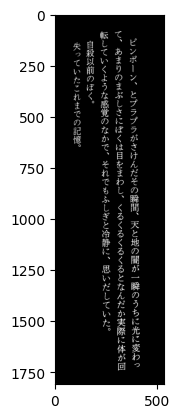

Found 5 lines


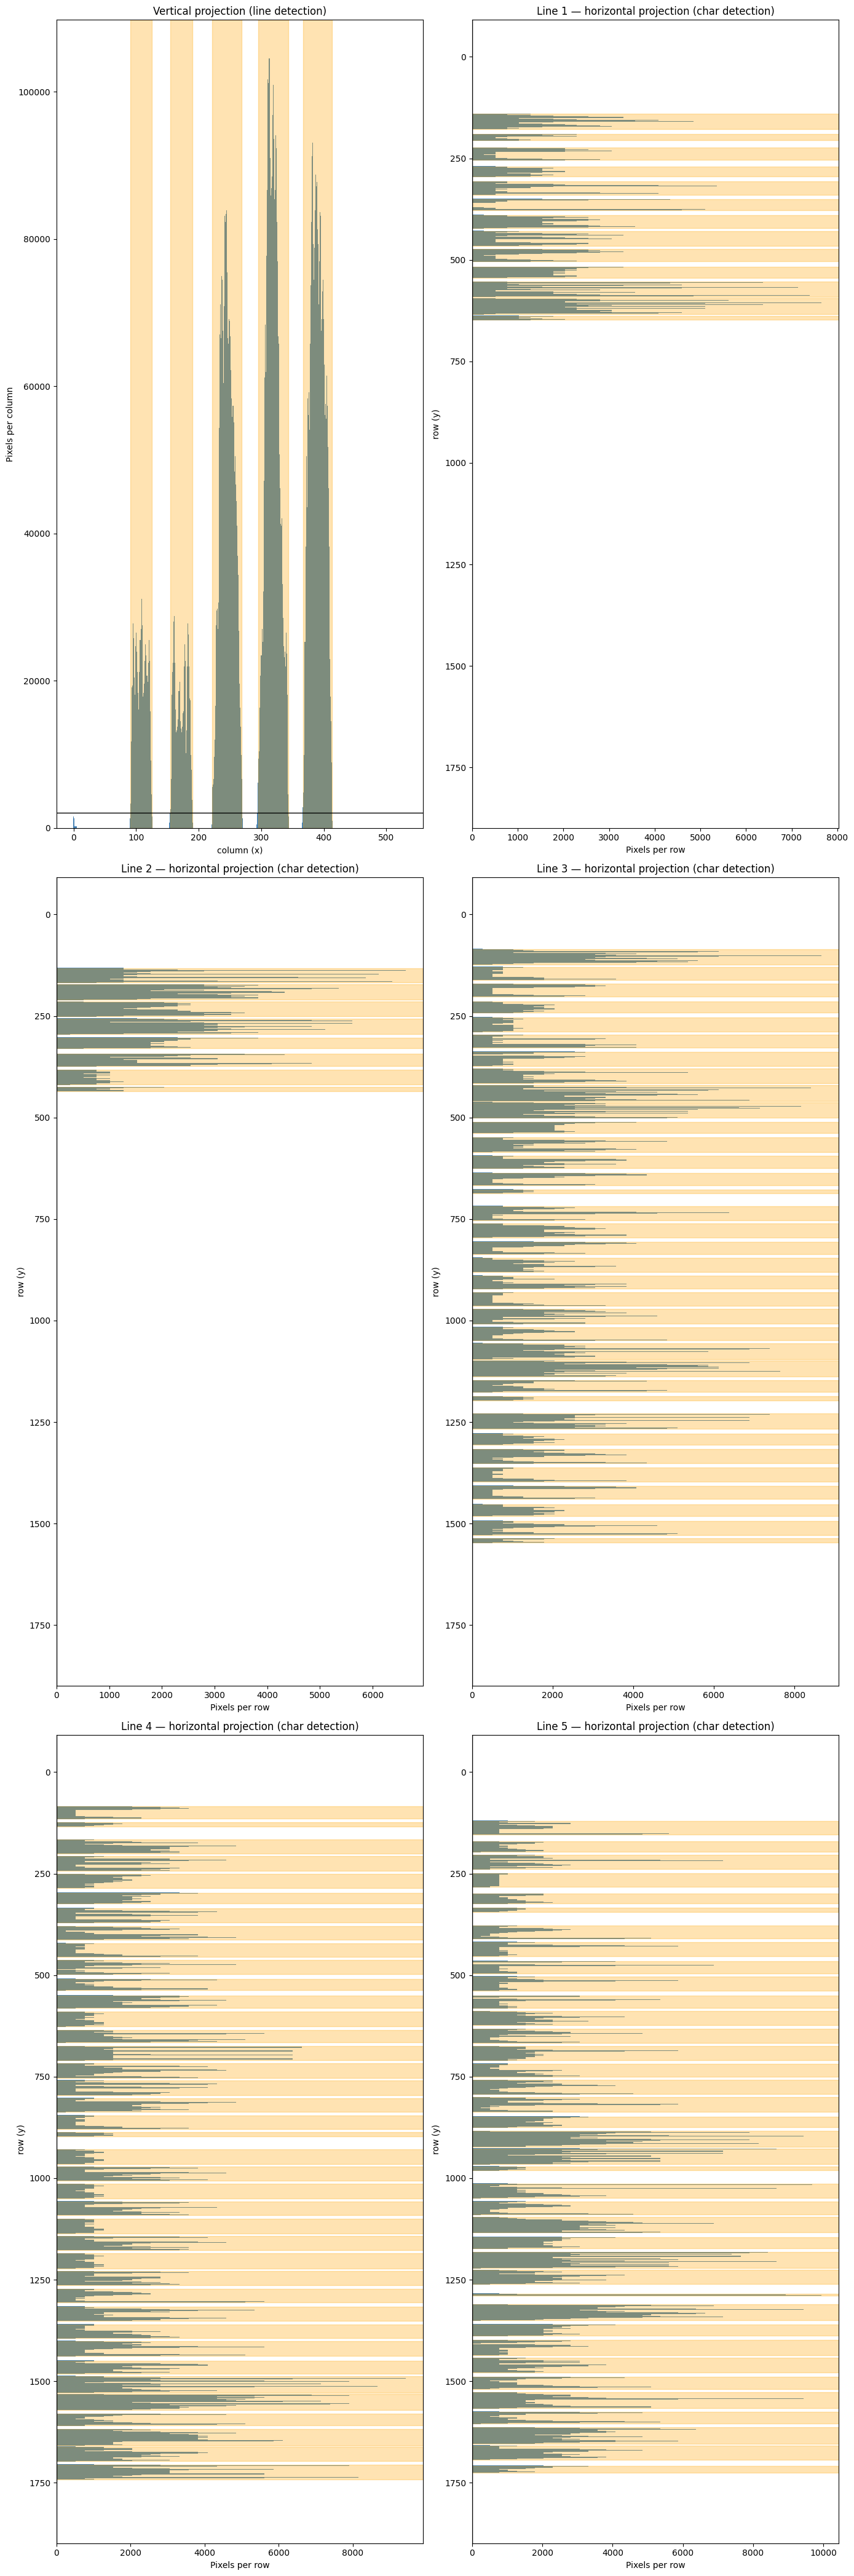

> Line 1: 13 character segments
> Line 2: 8 character segments
> Line 3: 35 character segments
> Line 4: 39 character segments
> Line 5: 38 character segments


In [6]:
def ShowHistogramProjection(lines, binary, line_ink_threshold, line_merge_gap, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness):
    H, W = binary.shape
    n_plots = 1 + len(lines)
    n_rows  = (n_plots + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 14 * n_rows))
    axes_flat = np.array(axes).flatten()

    ax = axes_flat[0]
    if ORIENTATION == 0:
        lineProj = binary.sum(axis=1)
        ax.barh(np.arange(H), lineProj, color="steelblue", height=1)
        for start, end in lines:
            ax.axhspan(start, end, color="orange", alpha=0.3)
        ax.axvline(x=np.max(lineProj) * line_ink_threshold, color="black", linewidth=1)
        ax.invert_yaxis()
        ax.set_title("Horizontal projection (line detection)")
        ax.set_xlabel("Pixels per row")
        ax.set_ylabel("row (y)")
    else:
        lineProj = binary.sum(axis=0)
        ax.bar(np.arange(W), lineProj, color="steelblue", width=1)
        for start, end in lines:
            ax.axvspan(start, end, color="orange", alpha=0.3)
        ax.axhline(y=np.max(lineProj) * line_ink_threshold, color="black", linewidth=1)
        ax.set_title("Vertical projection (line detection)")
        ax.set_xlabel("column (x)")
        ax.set_ylabel("Pixels per column")

    for i, (start, end) in enumerate(lines):
        ax    = axes_flat[i + 1]
        lineH = end - start + 1

        if ORIENTATION == 0:
            strip     = binary[start:end + 1, :]
            char_proj = strip.sum(axis=0)
            char_segs = DetectCharacters(strip, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness, lineH, ORIENTATION)
            ax.bar(np.arange(W), char_proj, color="steelblue", width=1)
            for x0, x1 in char_segs:
                ax.axvspan(x0, x1, color="orange", alpha=0.3)
            ax.axhline(y=np.max(char_proj) * char_ink_threshold, color="black", linewidth=1)
            ax.set_title(f"Line {i + 1} — vertical projection (char detection)")
            ax.set_xlabel("column (x)")
            ax.set_ylabel("Pixels per column")
        else:
            strip     = binary[:, start:end + 1]
            char_proj = strip.sum(axis=1)
            char_segs = DetectCharacters(strip, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness, lineH, ORIENTATION)
            ax.barh(np.arange(H), char_proj, color="steelblue", height=1)
            for y0, y1 in char_segs:
                ax.axhspan(y0, y1, color="orange", alpha=0.3)
            ax.axvline(x=np.max(char_proj) * char_ink_threshold, color="black", linewidth=1)
            ax.invert_yaxis()
            ax.set_title(f"Line {i + 1} — horizontal projection (char detection)")
            ax.set_xlabel("Pixels per row")
            ax.set_ylabel("row (y)")


    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    
def DetectAndPredict(binary, line_ink_threshold, line_merge_gap, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness, showImage = True, showDetails = False, showProjections = False):
    
   
    if showImage:
        ShowImage(binary)
   


    lines = DetectLines(binary, line_ink_threshold, line_merge_gap, ORIENTATION)
    if showDetails:
        print(f"Found {len(lines)} lines")

    if showProjections:
        ShowHistogramProjection(lines, binary, line_ink_threshold, line_merge_gap, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness)

    results = []  

    for lineID, (lineStart, lineEnd) in enumerate(lines):
        if ORIENTATION == 0:
            strip = binary[ lineStart : lineEnd+1, : ]
            grey_strip = grey[ lineStart : lineEnd+1 , : ]
        else:
            strip = binary[ :, lineStart : lineEnd+1 ]
            grey_strip = grey[ :, lineStart : lineEnd+1 ]

        charSegments  = DetectCharacters(strip, char_ink_threshold, char_merge_gap, char_min_width, max_fatness, max_thinness, lineEnd - lineStart + 1, ORIENTATION)
        
        if showDetails:
            print(f"> Line {lineID+1}: {len(charSegments)} character segments")

        lineResults = []
        for charStart, charEnd in charSegments:
            if ORIENTATION == 0:
                crop = grey_strip[:, charStart:charEnd+1]
                bbox = (charStart, lineStart, charEnd, lineEnd)
            else:
                crop = grey_strip[charStart:charEnd+1, :]
                bbox = (lineStart, charStart, lineEnd, charEnd)

            preds = Predict(crop)
            
            for char, prob in preds:
                if char in MINIMIZABLE_CHARACTERS.keys():
                    preds.append((MINIMIZABLE_CHARACTERS[char], prob))
                
            
            lineResults.append({"bbox": bbox, "preds": preds})

        results.append(lineResults)
    return results

grey, binary = LoadBinary(IMAGE_PATH)
results = DetectAndPredict(binary, LINE_INK_THRESHOLD, LINE_MERGE_GAP, CHAR_INK_THRESHOLD, CHAR_MERGE_GAP, CHAR_MIN_WIDTH, MAX_FATNESS, MAX_THINNESS, showImage=True, showDetails=True, showProjections=True)


## 5 · Visualise segmentation

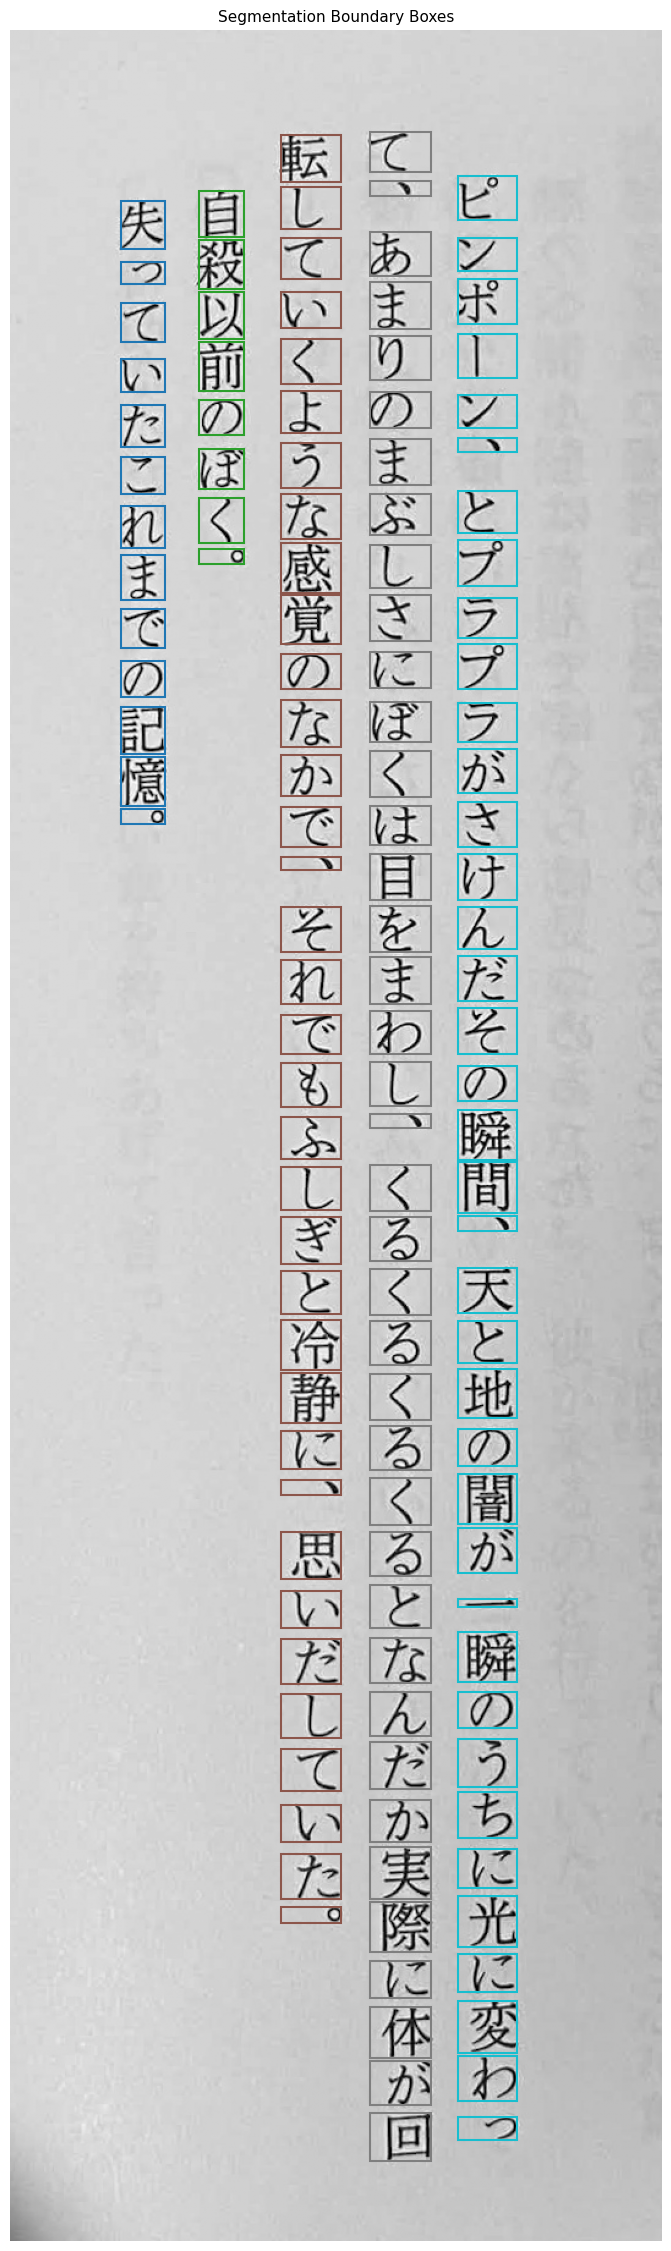

In [7]:
def VisualizeSegmentation(grey, results):
    W, H = grey.shape[1], grey.shape[0]
    fig, ax = plt.subplots(figsize=(max(10, W / 80), max(6, H / 80)))
    ax.imshow(grey, cmap="gray", vmin=0, vmax=255)

    colours = plt.cm.tab10(np.linspace(0, 1, max(len(results), 1)))

    for lineID, lineResults in enumerate(results):
        
        colour = colours[lineID]
        
        for char_data in lineResults:
            
            startX, startY, endX, endY = char_data["bbox"]
            
            #Box
            rect = mpatches.FancyBboxPatch((startX, startY), endX - startX, endY - startY, boxstyle="square,pad=1", linewidth=1.5, edgecolor=colour, facecolor="none")
            ax.add_patch(rect)
            
    ax.axis("off")
    ax.set_title("Segmentation Boundary Boxes", fontsize=11)
    plt.tight_layout()
    plt.show()

VisualizeSegmentation(grey, results)

## 6 · Reconstructed text

In [8]:
def ReconstructText(results, withLines=False):
    fullText = []

    if ORIENTATION == 1:
        results.reverse()

    for lineID, lineResults in enumerate(results):

        lineTxt = ""
        
        for char_data in lineResults:
            topChar, topConfidence = char_data["preds"][0]
            lineTxt += topChar if topConfidence >= CONFIDENCE_THRESHOLD else "🙈"
            
        fullText.append(lineTxt)

    return "\n".join(fullText) if withLines else print("".join(fullText))

print(ReconstructText(results, withLines=True))

ピンポしン、とプラプラがさけんだ亡の瞬間、天と地の闇が一瞬のろちに光に変わつ
て、あまり口求ぶしさにぼくは目をまわし、く石く石くるくるとなんだか実際に体が回
転していくよろな感覚のなかで、ぞれでどふしぎと恰静に、思いだしていた。
目殺以削のぼく。
失つていたこれまでの記憶。


## 7. Character Probabilities

In [9]:

def GetDisitrbutions(toPrint = True):
    sentenceDistributions = []
    sentenceID = -1
    for lineID, lineResults in enumerate(results):
        
        if toPrint:
            print(f"-- Line {lineID+1} --")
        
        for charID, charData in enumerate(lineResults):
            
            if toPrint:
                print(f"  Char {charID+1}:")
            
            sentenceDistributions.append([])
            sentenceID += 1
            
            for rank, (char, conf) in enumerate(charData["preds"]):
                
                bar = "█" * int(conf * 30)
                marker = " ◀" if rank == 0 else ""
                
                if toPrint:
                    print(f"    #{rank+1}  {char}  {conf*100:5.1f}%  {bar}{marker}")
                
                sentenceDistributions[sentenceID].append((char, conf))
    return sentenceDistributions

sentenceDistributions = GetDisitrbutions()

-- Line 1 --
  Char 1:
    #1  ピ  100.0%  █████████████████████████████ ◀
    #2  ビ    0.0%  
    #3  凹    0.0%  
    #4  ど    0.0%  
    #5  巴    0.0%  
  Char 2:
    #1  ン   99.9%  █████████████████████████████ ◀
    #2  シ    0.1%  
    #3  こ    0.0%  
    #4  ソ    0.0%  
    #5  し    0.0%  
  Char 3:
    #1  ポ   99.8%  █████████████████████████████ ◀
    #2  ぷ    0.1%  
    #3  が    0.0%  
    #4  ボ    0.0%  
    #5  将    0.0%  
  Char 4:
    #1  し   96.3%  ████████████████████████████ ◀
    #2  り    1.2%  
    #3  卜    0.8%  
    #4  十    0.8%  
    #5  よ    0.4%  
    #6  ょ    0.4%  
  Char 5:
    #1  ン   99.6%  █████████████████████████████ ◀
    #2  シ    0.4%  
    #3  ソ    0.0%  
    #4  し    0.0%  
    #5  こ    0.0%  
  Char 6:
    #1  、  100.0%  █████████████████████████████ ◀
    #2  。    0.0%  
    #3  い    0.0%  
    #4  へ    0.0%  
    #5  ヘ    0.0%  
  Char 7:
    #1  と   89.2%  ██████████████████████████ ◀
    #2  ど    6.1%  █
    #3  亡    4.1%  █
    #4  さ    0.3%  
  

In [10]:
!pip install fugashi unidic_lite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 37.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 36.8 MB/s eta 0:00:00
  Created wheel for unidic_lite: filename=unidic_lite-1.0.8-py3-none-any.whl size=47658817 sha256=e93f9fe97df6686630b63de7f2b8f8541f18ba12c05cd08f244c7673602f059a
  Stored in directory: /root/.cache/pip/wheels/5e/1f/0f/4d43887e5476d956fae828ee9b6687becd5544d68b51ed633d
Successfully built unidic_lite


In [11]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

LM_NAME = "cl-tohoku/bert-base-japanese-char"
tokenizer = AutoTokenizer.from_pretrained(LM_NAME)
lm = AutoModelForMaskedLM.from_pretrained(LM_NAME)
lm.eval()
print("Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/478 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/15.7k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/359M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: cl-tohoku/bert-base-japanese-char
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded


In [12]:
def TransformerRerank(sentenceDistributions, alpha=0.6):

    n = len(sentenceDistributions)

    sequence = [candidates[0][0] for candidates in sentenceDistributions]

    for pos in range(n):
        
        candidates = sentenceDistributions[pos]  
        
        maskedSeq = sequence.copy()
        maskedSeq[pos] = "[MASK]"
        maskedText = "".join(maskedSeq)

        inputs  = tokenizer(maskedText, return_tensors="pt")
        maskID = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0][0]

        with torch.no_grad():
            logits = lm(**inputs).logits          
        transformerProbs = torch.softmax(logits[0, maskID], dim=-1)

       
        bestChar, bestScore = None, -1

        for char, cnnProb in candidates:
            
            token_ids = tokenizer.encode(char, add_special_tokens=False)
            if not token_ids:
                continue  

            transformerProb = float(transformerProbs[token_ids[0]])
            
            score = (1 - alpha) * cnnProb + alpha * transformerProb

            if score > bestScore:
                bestScore, bestChar = score, char

        if bestChar is not None:
            sequence[pos] = bestChar

    return sequence


corrected = TransformerRerank(sentenceDistributions, alpha=1)
print("CNN top-1: ", "".join(d[0][0] for d in sentenceDistributions))
print("Corrected: ", "".join(corrected))

CNN top-1:  ピンポしン、とプラプラがさけんだ亡の瞬間、天と地の闇が一瞬のろちに光に変わつて、あまり口求ぶしさにぼくは目をまわし、く石く石くるくるとなんだか実際に体が回転していくよろな感覚のなかで、ぞれでどふしぎと恰静に、思いだしていた。目殺以削のぼく。失つていたこれまでの記憶。
Corrected:  ピンポよしいとプラプラがさけんだその瞬間、天と地の間が一瞬のうちに光に変わって、あまりのまぶしさにぼくは目をまわし、くるくるくるくるとなんだが実際に体が回転していくような感覚のなかで、それでもふしぎと袷静に、思いだしていた。自殺以前のぼくく失っていたこれまでの記憶。


## 8. BookData Evaluation

Runs the full pipeline on every image in `BookData/`, compares the predicted text against the ground-truth transcriptions, and returns per-image character accuracy (`1 − CER`).

In [14]:

BOOK_DATA_PATH = "drive/MyDrive/ETL9B/BookData"

def GetLevenshtein(sent1, sent2):
    m, n = len(sent1), len(sent2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            dp[j] = prev if sent1[i-1] == sent2[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[n]

def GetAccuracy(predicted, truth):
    return max(0.0, 1.0 - GetLevenshtein(predicted, truth) / len(truth))

def SegmentHistogram(grey, binary):
    lines = DetectLines(binary, LINE_INK_THRESHOLD, LINE_MERGE_GAP, ORIENTATION)
    columns = []
    
    for lineStart, lineEnd in lines:
        strip = binary[:, lineStart:lineEnd + 1]
        grey_strip = grey  [:, lineStart:lineEnd + 1]
        char_segs = DetectCharacters(strip, CHAR_INK_THRESHOLD, CHAR_MERGE_GAP, CHAR_MIN_WIDTH, MAX_FATNESS, MAX_THINNESS, lineEnd - lineStart + 1, ORIENTATION)
        columns.append([grey_strip[cs:ce + 1, :] for cs, ce in char_segs])

    columns.reverse()
    return [crop for col in columns for crop in col]


def SegmentOpenCV(grey, binary, min_area=200, col_gap=0):
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,2))
    dilated = cv2.dilate(binary, kernel)
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(dilated, connectivity=8)


    boxes = [
        (int(stats[i, cv2.CC_STAT_LEFT]),
         int(stats[i, cv2.CC_STAT_TOP]),
         int(stats[i, cv2.CC_STAT_WIDTH]),
         int(stats[i, cv2.CC_STAT_HEIGHT]))
        for i in range(1, n_labels)
        if stats[i, cv2.CC_STAT_AREA] >= min_area
    ]
    if not boxes:
        return []

    boxes.sort(key=lambda b: b[0] + b[2] / 2)
    columns = [[boxes[0]]]
    for box in boxes[1:]:
        col_x_max = max(b[0] + b[2] for b in columns[-1])
        if box[0] > col_x_max + col_gap:
            columns.append([box])
        else:
            columns[-1].append(box)

    columns.sort(key=lambda col: sum(b[0] + b[2] / 2 for b in col) / len(col), reverse=True)
    return [
        grey[y:y + h, x:x + w]
        for col in columns
        for x, y, w, h in sorted(col, key=lambda b: b[1])
    ]


def BuildDistributions(crops):
    distributions = []
    for crop in crops:
        preds = Predict(crop)
        extras = [(MINIMIZABLE_CHARACTERS[ch], p) for ch, p in preds if ch in MINIMIZABLE_CHARACTERS]
        preds.extend(extras)
        distributions.append(preds)
    return distributions

def ClassifyCNN(crops):
    distributions = BuildDistributions(crops)
    return "".join(
        preds[0][0]
        for preds in distributions
        if preds[0][1] >= CONFIDENCE_THRESHOLD
    )

def ClassifyCNNBert(crops):
    distributions = BuildDistributions(crops)
    return "".join(TransformerRerank(distributions, alpha=0.6))


PIPELINES = {
    "Histogram + CNN": (SegmentHistogram, ClassifyCNN),
    "Histogram + CNN + BERT": (SegmentHistogram, ClassifyCNNBert),
    "OpenCV + CNN": (SegmentOpenCV, ClassifyCNN),
    "OpenCV + CNN + BERT": (SegmentOpenCV, ClassifyCNNBert),
}

def RunPipeline(image_path, segment_fn, classify_fn):
    grey, binary = LoadBinary(image_path)
    crops = segment_fn(grey, binary)
    return classify_fn(crops)


with open(f"{BOOK_DATA_PATH}/transcriptions.json", "r", encoding="utf-8") as f:
    data = json.load(f)

allScores = {name: [] for name in PIPELINES}

for entry in data:
    file_name = entry["file_name"]
    label = entry["transcription"]
    img_path  = f"{BOOK_DATA_PATH}/{file_name}.png"
    print(f"▶ {file_name}")

    
    
    for name, (seg_fn, clf_fn) in PIPELINES.items():
        predicted = RunPipeline(img_path, seg_fn, clf_fn)
        acc = GetAccuracy(predicted, label)
        allScores[name].append(acc)
        print(f"  {name:<30s}: {acc:.1%}")
    print()

print("─" * 52)
print(f"{'Pipeline':<30s} Mean accuracy")
print("─" * 52)
for name, scores in allScores.items():
    print(f"{name:<30s}   {np.mean(scores):.1%}")
print("─" * 52)

allScores


▶ Karafuru_1
  Histogram + CNN               : 87.8%
  Histogram + CNN + BERT        : 96.2%
  OpenCV + CNN                  : 71.0%
  OpenCV + CNN + BERT           : 74.0%

▶ Karafuru_2
  Histogram + CNN               : 80.0%
  Histogram + CNN + BERT        : 82.2%
  OpenCV + CNN                  : 57.8%
  OpenCV + CNN + BERT           : 57.8%

▶ KasaNoSashikataWakaranai_1
  Histogram + CNN               : 79.3%
  Histogram + CNN + BERT        : 90.4%
  OpenCV + CNN                  : 52.9%
  OpenCV + CNN + BERT           : 59.1%

▶ KasaNoSashikataWakaranai_2
  Histogram + CNN               : 79.1%
  Histogram + CNN + BERT        : 92.5%
  OpenCV + CNN                  : 51.5%
  OpenCV + CNN + BERT           : 56.0%

▶ KimiNoNaWa_1
  Histogram + CNN               : 86.4%
  Histogram + CNN + BERT        : 100.0%
  OpenCV + CNN                  : 68.2%
  OpenCV + CNN + BERT           : 75.0%

▶ KimiNoNaWa_2
  Histogram + CNN               : 61.7%
  Histogram + CNN + BERT        : 74.5%


{'Histogram + CNN': [0.8778625954198473,
  0.8,
  0.7932692307692308,
  0.791044776119403,
  0.8636363636363636,
  0.6170212765957447,
  0.8,
  0.6746987951807228,
  0.7142857142857143,
  0.7580645161290323,
  0.5434782608695652,
  0.6911764705882353,
  0.5555555555555556,
  0.7931034482758621,
  0.8333333333333334,
  0.4158415841584159],
 'Histogram + CNN + BERT': [0.9618320610687023,
  0.8222222222222222,
  0.9038461538461539,
  0.9253731343283582,
  1.0,
  0.7446808510638299,
  0.9142857142857143,
  0.7710843373493976,
  0.8571428571428572,
  0.8709677419354839,
  0.6304347826086957,
  0.8235294117647058,
  0.6736111111111112,
  0.9195402298850575,
  0.8985507246376812,
  0.4356435643564357],
 'OpenCV + CNN': [0.7099236641221374,
  0.5777777777777777,
  0.5288461538461539,
  0.5149253731343284,
  0.6818181818181819,
  0.3829787234042553,
  0.6857142857142857,
  0.5060240963855422,
  0.3877551020408163,
  0.5967741935483871,
  0.4130434782608695,
  0.5661764705882353,
  0.36805555555